# **Problem Statement**


## Business Context


Renewable energy sources play an increasingly important role in the global energy mix, as the effort to reduce the environmental impact of energy production increases.

Out of all the renewable energy alternatives, wind energy is one of the most developed technologies worldwide. The U.S Department of Energy has put together a guide to achieving operational efficiency using predictive maintenance practices.

Predictive maintenance uses sensor information and analysis methods to measure and predict degradation and future component capability. The idea behind predictive maintenance is that failure patterns are predictable and if component failure can be predicted accurately and the component is replaced before it fails, the costs of operation and maintenance will be much lower.

The sensors fitted across different machines involved in the process of energy generation collect data related to various environmental factors (temperature, humidity, wind speed, etc.) and additional features related to various parts of the wind turbine (gearbox, tower, blades, break, etc.).


## Objective


“ReneWind” is a company working on improving the machinery/processes involved in the production of wind energy using machine learning and has collected data of generator failure of wind turbines using sensors. They have shared a ciphered version of the data, as the data collected through sensors is confidential (the type of data collected varies with companies). Data has 40 predictors, 20000 observations in the training set and 5000 in the test set.

The objective is to build various classification models, tune them, and find the best one that will help identify failures so that the generators could be repaired before failing/breaking to reduce the overall maintenance cost.
The nature of predictions made by the classification model will translate as follows:

- True positives (TP) are failures correctly predicted by the model. These will result in repairing costs.
- False negatives (FN) are real failures where there is no detection by the model. These will result in replacement costs.
- False positives (FP) are detections where there is no failure. These will result in inspection costs.

It is given that the cost of repairing a generator is much less than the cost of replacing it, and the cost of inspection is less than the cost of repair.

“1” in the target variables should be considered as “failure” and “0” represents “No failure”.


## Data Description


The data provided is a transformed version of the original data which was collected using sensors.

- Train.csv - To be used for training and tuning of models.
- Test.csv - To be used only for testing the performance of the final best model.

Both the datasets consist of 40 predictor variables and 1 target variable.


# **Installing and Importing the necessary libraries**


In [3]:
# Installing the libraries with the specified version
import sys 
!{sys.executable} -m pip install numpy==2.0.2 pandas==2.2.2 matplotlib==3.10.0 seaborn==0.13.2 scikit-learn==1.6.1 scipy joblib threadpoolctl tensorflow==2.19.0

  Using cached joblib-1.5.3-py3-none-any.whl.metadata (5.5 kB)
  Using cached absl_py-2.4.0-py3-none-any.whl.metadata (3.3 kB)
  Using cached astunparse-1.6.3-py2.py3-none-any.whl.metadata (4.4 kB)
  Using cached gast-0.7.0-py3-none-any.whl.metadata (1.5 kB)
  Using cached google_pasta-0.2.0-py3-none-any.whl.metadata (814 bytes)
  Using cached opt_einsum-3.4.0-py3-none-any.whl.metadata (6.3 kB)
  Using cached requests-2.32.5-py3-none-any.whl.metadata (4.9 kB)
  Using cached grpcio-1.78.0-cp312-cp312-win_amd64.whl.metadata (3.9 kB)
  Using cached tensorboard-2.19.0-py3-none-any.whl.metadata (1.8 kB)
  Using cached keras-3.13.2-py3-none-any.whl.metadata (6.3 kB)
  Using cached h5py-3.16.0-cp312-cp312-win_amd64.whl.metadata (3.1 kB)
  Using cached ml_dtypes-0.5.4-cp312-cp312-win_amd64.whl.metadata (9.2 kB)
  Using cached charset_normalizer-3.4.6-cp312-cp312-win_amd64.whl.metadata (41 kB)
  Using cached idna-3.11-py3-none-any.whl.metadata (8.4 kB)
  Using cached certifi-2026.2.25-py3-none-

**Note**:

- After running the above cell, kindly restart the runtime (for Google Colab) or notebook kernel (for Jupyter Notebook), and run all cells sequentially from the next cell.
- On executing the above line of code, you might see a warning regarding package dependencies. This error message can be ignored as the above code ensures that all necessary libraries and their dependencies are maintained to successfully execute the code in **_this notebook_**.


# **Loading the Data**


In [12]:
# Import necessary libraries
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.optimizers import SGD, Adam
from tensorflow.keras.callbacks import EarlyStopping
import os

os.listdir()

pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 200)

train_df = pd.read_csv("data/Train.csv")
test_df = pd.read_csv("data/Test.csv")

print("Train shape:", train_df.shape)
print("Test shape:", test_df.shape)

display(train_df.head())
display(test_df.head())

Train shape: (20000, 41)
Test shape: (5000, 41)


,V1,V2,V3,V4,V5,V6,V7,V8,V9,V10,V11,V12,V13,V14,V15,V16,V17,V18,V19,V20,V21,V22,V23,V24,V25,V26,V27,V28,V29,V30,V31,V32,V33,V34,V35,V36,V37,V38,V39,V40,Target
0,-4.464606,-4.679129,3.101546,0.506130,-0.221083,-2.032511,-2.910870,0.050714,-1.522351,3.761892,-5.714719,0.735893,0.981251,1.417884,-3.375815,-3.047303,0.306194,2.914097,2.269979,4.394876,-2.388299,0.646388,-1.190508,3.132986,0.665277,-2.510846,-0.036744,0.726218,-3.982187,-1.072638,1.667098,3.059700,-1.690440,2.846296,2.235198,6.667486,0.443809,-2.369169,2.950578,-3.480324,0
1,3.365912,3.653381,0.909671,-1.367528,0.332016,2.358938,0.732600,-4.332135,0.565695,-0.101080,1.914465,-0.951458,-1.255259,-2.706522,0.193223,-4.769379,-2.205319,0.907716,0.756894,-5.833678,-3.065122,1.596647,-1.757311,1.766444,-0.267098,3.625036,1.500346,-0.585712,0.783034,-0.201217,0.024883,-1.795474,3.032780,-2.467514,1.894599,-2.297780,-1.731048,5.908837,-0.386345,0.616242,0
2,-3.831843,-5.824444,0.634031,-2.418815,-1.773827,1.016824,-2.098941,-3.173204,-2.081860,5.392621,-0.770673,1.106718,1.144261,0.943301,-3.163804,-4.247825,-4.038909,3.688534,3.311196,1.059002,-2.143026,1.650120,-1.660592,1.679910,-0.450782,-4.550695,3.738779,1.134404,-2.033531,0.840839,-1.600395,-0.257101,0.803550,4.086219,2.292138,5.360850,0.351993,2.940021,3.839160,-4.309402,0
3,1.618098,1.888342,7.046143,-1.147285,0.083080,-1.529780,0.207309,-2.493629,0.344926,2.118578,-3.053023,0.459719,2.704527,-0.636086,-0.453717,-3.174046,-3.404347,-1.281536,1.582104,-1.951778,-3.516555,-1.206011,-5.627854,-1.817653,2.124142,5.294642,4.748137,-2.308536,-3.962977,-6.028730,4.948770,-3.584425,-2.577474,1.363769,0.622714,5.550100,-1.526796,0.138853,3.101430,-1.277378,0
4,-0.111440,3.872488,-3.758361,-2.982897,3.792714,0.544960,0.205433,4.848994,-1.854920,-6.220023,1.998347,4.723757,0.709113,-1.989432,-2.632684,4.184447,2.245356,3.734452,-6.312766,-5.379918,-0.886667,2.061694,9.445586,4.489976,-3.945144,4.582065,-8.780422,-3.382967,5.106507,6.787513,2.044184,8.265896,6.629213,-10.068689,1.222987,-3.229763,1.686909,-2.163896,-3.644622,6.510338,0


,V1,V2,V3,V4,V5,V6,V7,V8,V9,V10,V11,V12,V13,V14,V15,V16,V17,V18,V19,V20,V21,V22,V23,V24,V25,V26,V27,V28,V29,V30,V31,V32,V33,V34,V35,V36,V37,V38,V39,V40,Target
0,-0.613489,-3.819640,2.202302,1.300420,-1.184929,-4.495964,-1.835817,4.722989,1.206140,-0.341909,-5.122874,1.017021,4.818549,3.269001,-2.984330,1.387370,2.032002,-0.511587,-1.023069,7.338733,-2.242244,0.155489,2.053786,-2.772273,1.851369,-1.788696,-0.277282,-1.255143,-3.832886,-1.504542,1.586765,2.291204,-5.411388,0.870073,0.574479,4.157191,1.428093,-10.511342,0.454664,-1.448363,0
1,0.389608,-0.512341,0.527053,-2.576776,-1.016766,2.235112,-0.441301,-4.405744,-0.332869,1.966794,1.796544,0.410490,0.638328,-1.389600,-1.883410,-5.017922,-3.827238,2.418060,1.762285,-3.242297,-3.192960,1.857454,-1.707954,0.633444,-0.587898,0.083683,3.013935,-0.182309,0.223917,0.865228,-1.782158,-2.474936,2.493582,0.315165,2.059288,0.683859,-0.485452,5.128350,1.720744,-1.488235,0
2,-0.874861,-0.640632,4.084202,-1.590454,0.525855,-1.957592,-0.695367,1.347309,-1.732348,0.466500,-4.928214,3.565070,-0.449329,-0.656246,-0.166537,-1.630207,2.291865,2.396492,0.601278,1.793534,-2.120238,0.481968,-0.840707,1.790197,1.874395,0.363930,-0.169063,-0.483832,-2.118982,-2.156586,2.907291,-1.318888,-2.997464,0.459664,0.619774,5.631504,1.323512,-1.752154,1.808302,1.675748,0
3,0.238384,1.458607,4.014528,2.534478,1.196987,-3.117330,-0.924035,0.269493,1.322436,0.702345,-5.578345,-0.850662,2.590525,0.767418,-2.390809,-2.341961,0.571875,-0.933751,0.508677,1.210715,-3.259524,0.104587,-0.658875,1.498107,1.100305,4.142988,-0.248446,-1.136516,-5.355810,-4.545931,3.808667,3.517918,-3.074085,-0.284220,0.954576,3.029331,-1.367198,-3.412140,0.906000,-2.450889,0
4,5.828225,2.768260,-1.234530,2.809264,-1.641648,-1.406698,0.568643,0.965043,1.918379,-2.774855,-0.530016,1.374544,-0.650941,-1.679466,-0.379220,-4.443143,3.893857,-0.607640,2.944931,0.367233,-5.789081,4.597528,4.450264,3.224941,0.396701,0.247765,-2.362047,1.079378,-0.473076,2.242810,-3.591421,1.773841,-1.501573,-2.226702,4.776830,-6.559698,-0.805551,-0.276007,-3.858207,-0.537694,0


# **Data Overview**


In [13]:
# ================================
# Data Overview
# ================================

print("Training Data Info")
print("-" * 40)
train_df.info()

print("\nTest Data Info")
print("-" * 40)
test_df.info()

print("\nSummary Statistics (Train)")
display(train_df.describe())

print("\nSummary Statistics (Test)")
display(test_df.describe())

print("\nMissing Values (Train)")
display(train_df.isnull().sum())

print("\nMissing Values (Test)")
display(test_df.isnull().sum())

print("\nDuplicate Rows in Train:", train_df.duplicated().sum())
print("Duplicate Rows in Test:", test_df.duplicated().sum())

Training Data Info
----------------------------------------
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20000 entries, 0 to 19999
Data columns (total 41 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   V1      19982 non-null  float64
 1   V2      19982 non-null  float64
 2   V3      20000 non-null  float64
 3   V4      20000 non-null  float64
 4   V5      20000 non-null  float64
 5   V6      20000 non-null  float64
 6   V7      20000 non-null  float64
 7   V8      20000 non-null  float64
 8   V9      20000 non-null  float64
 9   V10     20000 non-null  float64
 10  V11     20000 non-null  float64
 11  V12     20000 non-null  float64
 12  V13     20000 non-null  float64
 13  V14     20000 non-null  float64
 14  V15     20000 non-null  float64
 15  V16     20000 non-null  float64
 16  V17     20000 non-null  float64
 17  V18     20000 non-null  float64
 18  V19     20000 non-null  float64
 19  V20     20000 non-null  float64
 20  V21     2000

,V1,V2,V3,V4,V5,V6,V7,V8,V9,V10,V11,V12,V13,V14,V15,V16,V17,V18,V19,V20,V21,V22,V23,V24,V25,V26,V27,V28,V29,V30,V31,V32,V33,V34,V35,V36,V37,V38,V39,V40,Target
count,19982.000000,19982.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000
mean,-0.271996,0.440430,2.484699,-0.083152,-0.053752,-0.995443,-0.879325,-0.548195,-0.016808,-0.012998,-1.895393,1.604825,1.580486,-0.950632,-2.414993,-2.925225,-0.134261,1.189347,1.181808,0.023608,-3.611252,0.951835,-0.366116,1.134389,-0.002186,1.873785,-0.612413,-0.883218,-0.985625,-0.015534,0.486842,0.303799,0.049825,-0.462702,2.229620,1.514809,0.011316,-0.344025,0.890653,-0.875630,0.055500
std,3.441625,3.150784,3.388963,3.431595,2.104801,2.040970,1.761626,3.295756,2.160568,2.193201,3.124322,2.930454,2.874658,1.789651,3.354974,4.221717,3.345462,2.592276,3.396925,3.669477,3.567690,1.651547,4.031860,3.912069,2.016740,3.435137,4.368847,1.917713,2.684365,3.005258,3.461384,5.500400,3.575285,3.183841,2.937102,3.800860,1.788165,3.948147,1.753054,3.012155,0.228959
min,-11.876451,-12.319951,-10.708139,-15.082052,-8.603361,-10.227147,-7.949681,-15.657561,-8.596313,-9.853957,-14.832058,-12.948007,-13.228247,-7.738593,-16.416606,-20.374158,-14.091184,-11.643994,-13.491784,-13.922659,-17.956231,-10.122095,-14.866128,-16.387147,-8.228266,-11.834271,-14.904939,-9.269489,-12.579469,-14.796047,-13.722760,-19.876502,-16.898353,-17.985094,-15.349803,-14.833178,-5.478350,-17.375002,-6.438880,-11.023935,0.000000
25%,-2.737146,-1.640674,0.206860,-2.347660,-1.535607,-2.347238,-2.030926,-2.642665,-1.494973,-1.411212,-3.922404,-0.396514,-0.223545,-2.170741,-4.415322,-5.634240,-2.215611,-0.403917,-1.050168,-2.432953,-5.930360,-0.118127,-3.098756,-1.468062,-1.365178,-0.337863,-3.652323,-2.171218,-2.787443,-1.867114,-1.817772,-3.420469,-2.242857,-2.136984,0.336191,-0.943809,-1.255819,-2.987638,-0.272250,-2.940193,0.000000
50%,-0.747917,0.471536,2.255786,-0.135241,-0.101952,-1.000515,-0.917179,-0.389085,-0.067597,0.100973,-1.921237,1.507841,1.637185,-0.957163,-2.382617,-2.682705,-0.014580,0.883398,1.279061,0.033415,-3.532888,0.974687,-0.262093,0.969048,0.025050,1.950531,-0.884894,-0.891073,-1.176181,0.184346,0.490304,0.052073,-0.066249,-0.255008,2.098633,1.566526,-0.128435,-0.316849,0.919261,-0.920806,0.000000
75%,1.840112,2.543967,4.566165,2.130615,1.340480,0.380330,0.223695,1.722965,1.409203,1.477045,0.118906,3.571454,3.459886,0.270677,-0.359052,-0.095046,2.068751,2.571770,3.493299,2.512372,-1.265884,2.025594,2.451750,3.545975,1.397112,4.130037,2.189177,0.375884,0.629773,2.036229,2.730688,3.761722,2.255134,1.436935,4.064358,3.983939,1.175533,2.279399,2.057540,1.119897,0.000000
max,15.493002,13.089269,17.090919,13.236381,8.133797,6.975847,8.006091,11.679495,8.137580,8.108472,11.826433,15.080698,15.419616,5.670664,12.246455,13.583212,16.756432,13.179863,13.237742,16.052339,13.840473,7.409856,14.458734,17.163291,8.223389,16.836410,17.560404,6.527643,10.722055,12.505812,17.255090,23.633187,16.692486,14.358213,15.291065,19.329576,7.467006,15.289923,7.759877,10.654265,1.000000



Summary Statistics (Test)


,V1,V2,V3,V4,V5,V6,V7,V8,V9,V10,V11,V12,V13,V14,V15,V16,V17,V18,V19,V20,V21,V22,V23,V24,V25,V26,V27,V28,V29,V30,V31,V32,V33,V34,V35,V36,V37,V38,V39,V40,Target
count,4995.000000,4994.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000
mean,-0.277622,0.397928,2.551787,-0.048943,-0.080120,-1.042138,-0.907922,-0.574592,0.030121,0.018524,-2.008615,1.576413,1.622456,-0.921097,-2.452174,-3.018503,-0.103721,1.195606,1.210490,0.138429,-3.664398,0.961960,-0.422182,1.088841,0.061235,1.847261,-0.552397,-0.867678,-1.095805,-0.118699,0.468810,0.232567,-0.080115,-0.392663,2.211205,1.594845,0.022931,-0.405659,0.938800,-0.932406,0.056400
std,3.466280,3.139562,3.326607,3.413937,2.110870,2.005444,1.769017,3.331911,2.174139,2.145437,3.112220,2.907401,2.882892,1.803470,3.387041,4.264407,3.336513,2.586403,3.384662,3.657171,3.577841,1.640414,4.056714,3.968207,2.010227,3.400330,4.402947,1.926181,2.655454,3.023292,3.446324,5.585628,3.538624,3.166101,2.948426,3.774970,1.785320,3.968936,1.716502,2.978193,0.230716
min,-12.381696,-10.716179,-9.237940,-14.682446,-7.711569,-8.924196,-8.124230,-12.252731,-6.785495,-8.170956,-13.151753,-8.164048,-11.548209,-7.813929,-15.285768,-20.985779,-13.418281,-12.214016,-14.169635,-13.719620,-16.340707,-6.740239,-14.422274,-12.315545,-6.770139,-11.414019,-13.177038,-7.933388,-9.987800,-12.438434,-11.263271,-17.244168,-14.903781,-14.699725,-12.260591,-12.735567,-5.079070,-15.334533,-5.451050,-10.076234,0.000000
25%,-2.743691,-1.649211,0.314931,-2.292694,-1.615238,-2.368853,-2.054259,-2.642088,-1.455712,-1.353320,-4.050432,-0.449674,-0.126012,-2.110952,-4.479072,-5.648343,-2.227683,-0.408850,-1.026394,-2.325454,-5.944369,-0.047728,-3.162690,-1.623203,-1.298377,-0.242470,-3.662591,-2.159811,-2.861373,-1.996743,-1.822421,-3.556267,-2.348121,-2.009604,0.321818,-0.866066,-1.240526,-2.984480,-0.208024,-2.986587,0.000000
50%,-0.764767,0.427369,2.260428,-0.145753,-0.131890,-1.048571,-0.939695,-0.357943,-0.079891,0.166292,-2.043122,1.488253,1.718649,-0.896011,-2.417131,-2.773763,0.047462,0.881395,1.295864,0.193386,-3.662870,0.986020,-0.279222,0.912815,0.076703,1.917032,-0.871982,-0.930695,-1.340547,0.112463,0.485742,-0.076694,-0.159713,-0.171745,2.111750,1.702964,-0.110415,-0.381162,0.959152,-1.002764,0.000000
75%,1.831313,2.444486,4.587000,2.166468,1.341197,0.307555,0.212228,1.712896,1.449548,1.511248,0.044069,3.562626,3.464604,0.272324,-0.432943,-0.178105,2.111907,2.604014,3.526278,2.539550,-1.329645,2.029321,2.425911,3.537195,1.428491,4.156106,2.247257,0.420587,0.521843,1.946450,2.779008,3.751857,2.099160,1.465402,4.031639,4.104409,1.237522,2.287998,2.130769,1.079738,0.000000
max,13.504352,14.079073,15.314503,12.140157,7.672835,5.067685,7.616182,10.414722,8.850720,6.598728,9.956400,12.983644,12.620041,5.734112,11.673420,13.975843,19.776592,13.642235,12.427997,13.870565,11.046925,7.505291,13.180887,17.806035,6.556937,17.528193,17.290161,7.415659,14.039466,10.314976,12.558928,26.539391,13.323517,12.146302,13.489237,17.116122,6.809938,13.064950,7.182237,8.698460,1.000000



Missing Values (Train)


V1        18
V2        18
V3         0
V4         0
V5         0
V6         0
V7         0
V8         0
V9         0
V10        0
V11        0
V12        0
V13        0
V14        0
V15        0
V16        0
V17        0
V18        0
V19        0
V20        0
V21        0
V22        0
V23        0
V24        0
V25        0
V26        0
V27        0
V28        0
V29        0
V30        0
V31        0
V32        0
V33        0
V34        0
V35        0
V36        0
V37        0
V38        0
V39        0
V40        0
Target     0
dtype: int64


Missing Values (Test)


V1        5
V2        6
V3        0
V4        0
V5        0
V6        0
V7        0
V8        0
V9        0
V10       0
V11       0
V12       0
V13       0
V14       0
V15       0
V16       0
V17       0
V18       0
V19       0
V20       0
V21       0
V22       0
V23       0
V24       0
V25       0
V26       0
V27       0
V28       0
V29       0
V30       0
V31       0
V32       0
V33       0
V34       0
V35       0
V36       0
V37       0
V38       0
V39       0
V40       0
Target    0
dtype: int64


Duplicate Rows in Train: 0
Duplicate Rows in Test: 0


# **Exploratory Data Analysis**


## Univariate analysis


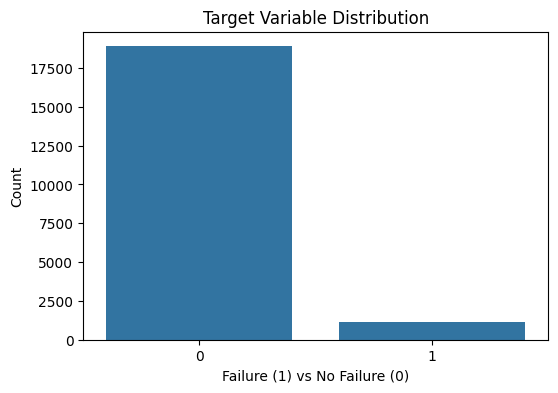

Target Value Counts:
Target
0    18890
1     1110
Name: count, dtype: int64

Target Percentage:
Target
0    94.45
1     5.55
Name: proportion, dtype: float64


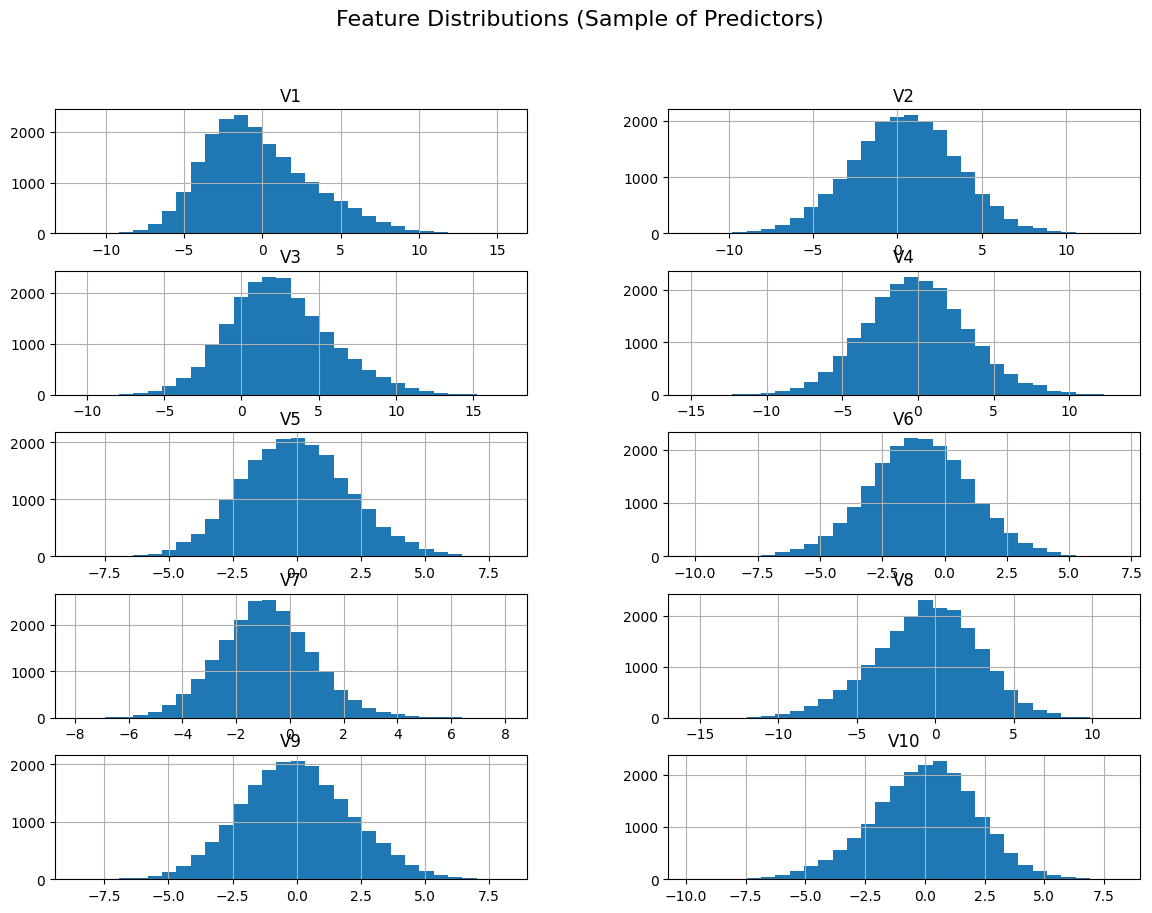

In [14]:
# ================================
# Univariate Analysis
# ================================

# Target variable distribution
plt.figure(figsize=(6,4))
sns.countplot(x=train_df["Target"])
plt.title("Target Variable Distribution")
plt.xlabel("Failure (1) vs No Failure (0)")
plt.ylabel("Count")
plt.show()

print("Target Value Counts:")
print(train_df["Target"].value_counts())

print("\nTarget Percentage:")
print(train_df["Target"].value_counts(normalize=True) * 100)


# Distribution of a few sample features
features = train_df.columns[:10]  # first 10 features for visualization

train_df[features].hist(
    bins=30,
    figsize=(14,10),
    layout=(5,2)
)

plt.suptitle("Feature Distributions (Sample of Predictors)", fontsize=16)
plt.show()

## Bivariate Analysis


Top correlations with Target:


Target    1.000000
V21       0.256411
V15       0.249118
V7        0.236907
V16       0.230507
V28       0.207359
V11       0.196715
V34       0.153854
V8        0.135996
V14       0.117586
Name: Target, dtype: float64


Lowest correlations with Target:


V33   -0.102548
V22   -0.134727
V31   -0.136951
V13   -0.139718
V35   -0.145603
V26   -0.180469
V3    -0.213855
V36   -0.216453
V39   -0.227264
V18   -0.293340
Name: Target, dtype: float64

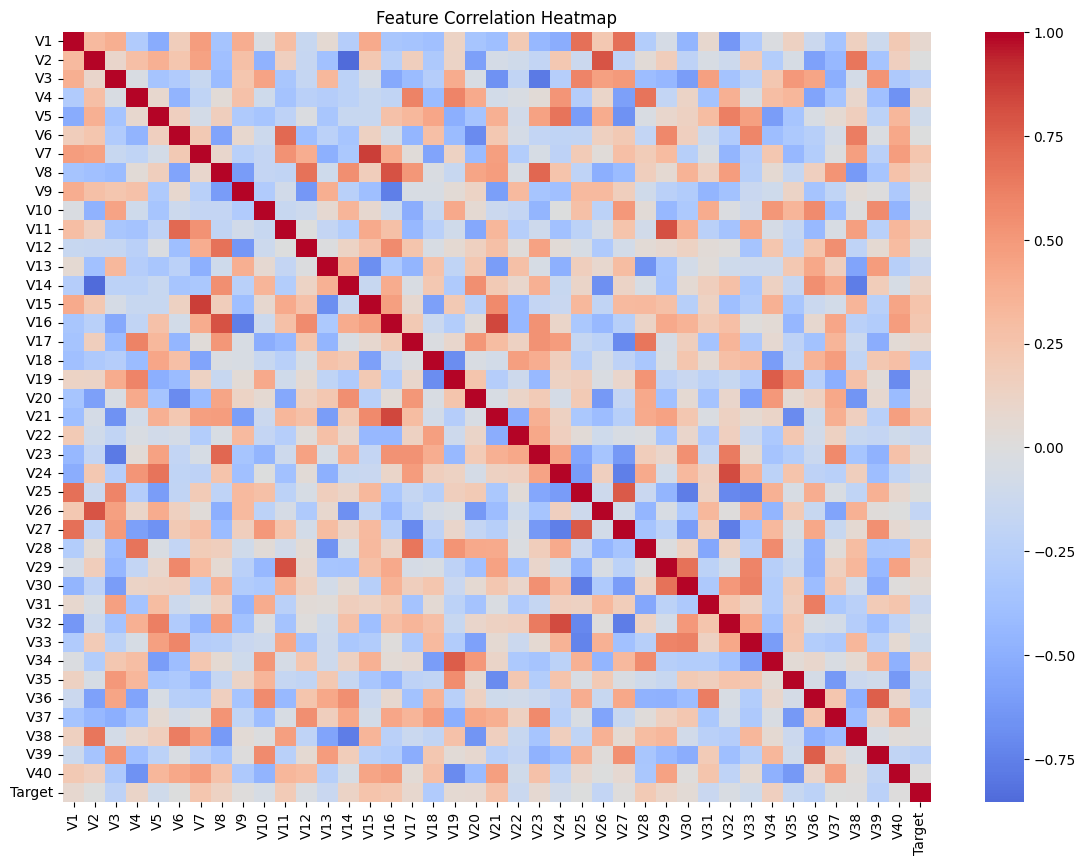

In [15]:
# ================================
# Bivariate Analysis
# ================================

# Correlation with Target
corr_with_target = train_df.corr()["Target"].sort_values(ascending=False)

print("Top correlations with Target:")
display(corr_with_target.head(10))

print("\nLowest correlations with Target:")
display(corr_with_target.tail(10))


# Correlation heatmap
plt.figure(figsize=(14,10))
sns.heatmap(train_df.corr(), cmap="coolwarm", center=0)
plt.title("Feature Correlation Heatmap")
plt.show()

The dataset shows significant class imbalance with only 5.55% of observations corresponding to generator failures. Since missing a failure (false negative) leads to expensive generator replacement costs, evaluation metrics such as Recall and F1-score are more appropriate than accuracy.


# **Data Preprocessing**


In [16]:
# ==========================================
# Data Preprocessing
# ==========================================

# Separate features and target from training data
X = train_df.drop(columns="Target")
y = train_df["Target"]

# Separate features and target from test data
X_test = test_df.drop(columns="Target")
y_test = test_df["Target"]

# Missing value treatment
# Only V1 and V2 have a very small number of missing values,
# so we use median imputation.
train_medians = X.median()

X = X.fillna(train_medians)
X_test = X_test.fillna(train_medians)   # use train medians to avoid data leakage

# Train-validation split
X_train, X_val, y_train, y_val = train_test_split(
    X,
    y,
    test_size=0.2,
    stratify=y,
    random_state=42
)

# Feature scaling
# Fit scaler only on training data to avoid data leakage
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)
X_test_scaled = scaler.transform(X_test)

# Quick checks
print("X_train shape:", X_train.shape)
print("X_val shape:", X_val.shape)
print("X_test shape:", X_test.shape)

print("\nMissing values after imputation:")
print("X_train:", pd.DataFrame(X_train).isnull().sum().sum())
print("X_val:", pd.DataFrame(X_val).isnull().sum().sum())
print("X_test:", pd.DataFrame(X_test).isnull().sum().sum())

print("\nTarget distribution in training set:")
print(y_train.value_counts(normalize=True) * 100)

print("\nTarget distribution in validation set:")
print(y_val.value_counts(normalize=True) * 100)

X_train shape: (16000, 40)
X_val shape: (4000, 40)
X_test shape: (5000, 40)

Missing values after imputation:
X_train: 0
X_val: 0
X_test: 0

Target distribution in training set:
Target
0    94.45
1     5.55
Name: proportion, dtype: float64

Target distribution in validation set:
Target
0    94.45
1     5.55
Name: proportion, dtype: float64


# **Model Building**


## Model Evaluation Criterion


The dataset is heavily skewed, with generator failures making up only 5.55% of the total observations. In this context, a False Negative (missing a failure) is the worst-case scenario; the cost of a full generator replacement far outweighs the price of a proactive inspection or minor repair.

Because of this lopsided risk, standard accuracy is a misleading metric. Instead, the focus shifts to Recall and the F1-Score


## Initial Model Building (Model 0)


- Let's start with a neural network consisting of
  - just one hidden layer
  - activation function of ReLU
  - SGD as the optimizer


In [ ]:
# ==========================================
# Model 0: Baseline Neural Network
# ==========================================

model_0 = Sequential()

# Hidden layer
model_0.add(Dense(32, activation="relu", input_dim=X_train_scaled.shape[1]))

# Output layer
model_0.add(Dense(1, activation="sigmoid"))

# Compile model
optimizer = SGD(learning_rate=0.01)

model_0.compile(
    optimizer=optimizer,
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

# Train model
history_0 = model_0.fit(
    X_train_scaled,
    y_train,
    validation_data=(X_val_scaled, y_val),
    epochs=20,
    batch_size=32,
    verbose=1
)

Epoch 1/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9170 - loss: 0.2574 - val_accuracy: 0.9517 - val_loss: 0.1662
Epoch 2/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9588 - loss: 0.1433 - val_accuracy: 0.9628 - val_loss: 0.1336
Epoch 3/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9673 - loss: 0.1219 - val_accuracy: 0.9685 - val_loss: 0.1176
Epoch 4/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9706 - loss: 0.1101 - val_accuracy: 0.9715 - val_loss: 0.1076
Epoch 5/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9728 - loss: 0.1022 - val_accuracy: 0.9745 - val_loss: 0.1004
Epoch 6/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9749 - loss: 0.0963 - val_accuracy: 0.9758 - val_loss: 0.0952
Epoch 7/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9762 - loss: 0.0917 - val_accuracy: 0.9768 - val_loss: 0.0909
Epoch 8/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9774 - loss: 0.0879 - val_accuracy: 0.

### Model 0 Evalutation


In [18]:
# ==========================================
# Model 0 Performance
# ==========================================

y_val_pred_prob = model_0.predict(X_val_scaled)
y_val_pred = (y_val_pred_prob > 0.5).astype(int)

print("Confusion Matrix")
print(confusion_matrix(y_val, y_val_pred))

print("\nClassification Report")
print(classification_report(y_val, y_val_pred))

125/125 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step  
Confusion Matrix
[[3775    3]
 [  53  169]]

Classification Report
              precision    recall  f1-score   support

           0       0.99      1.00      0.99      3778
           1       0.98      0.76      0.86       222

    accuracy                           0.99      4000
   macro avg       0.98      0.88      0.93      4000
weighted avg       0.99      0.99      0.99      4000



# **Model Performance Improvement**


### Helper functions


In [19]:
# ==========================================
# Class Weights
# ==========================================

class_weights = compute_class_weight(
    class_weight="balanced",
    classes=np.unique(y_train),
    y=y_train
)

class_weights = dict(enumerate(class_weights))
print("Class Weights:", class_weights)

# ==========================================
# Evaluation Function
# ==========================================

def evaluate_model(model, X_train_scaled, y_train, X_val_scaled, y_val, model_name="Model"):
    y_train_pred = (model.predict(X_train_scaled) > 0.5).astype(int)
    y_val_pred = (model.predict(X_val_scaled) > 0.5).astype(int)

    train_precision = precision_score(y_train, y_train_pred)
    train_recall = recall_score(y_train, y_train_pred)
    train_f1 = f1_score(y_train, y_train_pred)

    val_precision = precision_score(y_val, y_val_pred)
    val_recall = recall_score(y_val, y_val_pred)
    val_f1 = f1_score(y_val, y_val_pred)

    print(f"{model_name} - Training Performance")
    print(classification_report(y_train, y_train_pred))

    print(f"\n{model_name} - Validation Performance")
    print(classification_report(y_val, y_val_pred))

    return {
        "Model": model_name,
        "Train Precision": train_precision,
        "Train Recall": train_recall,
        "Train F1": train_f1,
        "Val Precision": val_precision,
        "Val Recall": val_recall,
        "Val F1": val_f1
    }

Class Weights: {0: np.float64(0.5293806246691372), 1: np.float64(9.00900900900901)}


## Model 1


In [20]:
# ==========================================
# Model 1
# More hidden layers + SGD
# ==========================================

model_1 = Sequential([
    Dense(64, activation="relu", input_dim=X_train_scaled.shape[1]),
    Dense(32, activation="relu"),
    Dense(1, activation="sigmoid")
])

model_1.compile(
    optimizer=SGD(learning_rate=0.01),
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

history_1 = model_1.fit(
    X_train_scaled, y_train,
    validation_data=(X_val_scaled, y_val),
    epochs=20,
    batch_size=32,
    verbose=1
)

results_1 = evaluate_model(model_1, X_train_scaled, y_train, X_val_scaled, y_val, "Model 1")

Epoch 1/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9301 - loss: 0.2229 - val_accuracy: 0.9463 - val_loss: 0.1572
Epoch 2/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9589 - loss: 0.1358 - val_accuracy: 0.9655 - val_loss: 0.1240
Epoch 3/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9711 - loss: 0.1127 - val_accuracy: 0.9747 - val_loss: 0.1057
Epoch 4/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9753 - loss: 0.0990 - val_accuracy: 0.9787 - val_loss: 0.0941
Epoch 5/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - accuracy: 0.9777 - loss: 0.0893 - val_accuracy: 0.9800 - val_loss: 0.0863
Epoch 6/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.9798 - loss: 0.0821 - val_accuracy: 0.9818 - val_loss: 0.0807
Epoch 7/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9821 - loss: 0.0767 - val_accuracy: 0.9840 - val_loss: 0.0761
Epoch 8/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9837 - loss: 0.0723 - val_accuracy: 0.

## Model 2


In [21]:
# ==========================================
# Model 2
# One hidden layer + Adam
# ==========================================

model_2 = Sequential([
    Dense(32, activation="relu", input_dim=X_train_scaled.shape[1]),
    Dense(1, activation="sigmoid")
])

model_2.compile(
    optimizer=Adam(learning_rate=0.001),
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

history_2 = model_2.fit(
    X_train_scaled, y_train,
    validation_data=(X_val_scaled, y_val),
    epochs=20,
    batch_size=32,
    verbose=1
)

results_2 = evaluate_model(model_2, X_train_scaled, y_train, X_val_scaled, y_val, "Model 2")

Epoch 1/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.9536 - loss: 0.1672 - val_accuracy: 0.9760 - val_loss: 0.1025
Epoch 2/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9780 - loss: 0.0875 - val_accuracy: 0.9840 - val_loss: 0.0780
Epoch 3/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9842 - loss: 0.0717 - val_accuracy: 0.9865 - val_loss: 0.0686
Epoch 4/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9860 - loss: 0.0643 - val_accuracy: 0.9890 - val_loss: 0.0626
Epoch 5/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9875 - loss: 0.0599 - val_accuracy: 0.9870 - val_loss: 0.0625
Epoch 6/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9881 - loss: 0.0575 - val_accuracy: 0.9905 - val_loss: 0.0577
Epoch 7/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9887 - loss: 0.0553 - val_accuracy: 0.9893 - val_loss: 0.0558
Epoch 8/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9889 - loss: 0.0544 - val_accuracy: 0.

## Model 3


In [25]:
# ==========================================
# Model 3
# More hidden layers + Adam
# ==========================================

model_3 = Sequential([
    Dense(64, activation="relu", input_dim=X_train_scaled.shape[1]),
    Dense(32, activation="relu"),
    Dense(1, activation="sigmoid")
])

model_3.compile(
    optimizer=Adam(learning_rate=0.001),
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

history_3 = model_3.fit(
    X_train_scaled, y_train,
    validation_data=(X_val_scaled, y_val),
    epochs=20,
    batch_size=32,
    verbose=1
)

results_3 = evaluate_model(model_3, X_train_scaled, y_train, X_val_scaled, y_val, "Model 3")

Epoch 1/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.9616 - loss: 0.1337 - val_accuracy: 0.9837 - val_loss: 0.0767
Epoch 2/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9868 - loss: 0.0647 - val_accuracy: 0.9915 - val_loss: 0.0575
Epoch 3/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.9898 - loss: 0.0530 - val_accuracy: 0.9908 - val_loss: 0.0497
Epoch 4/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9905 - loss: 0.0481 - val_accuracy: 0.9933 - val_loss: 0.0443
Epoch 5/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.9915 - loss: 0.0438 - val_accuracy: 0.9935 - val_loss: 0.0423
Epoch 6/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9924 - loss: 0.0416 - val_accuracy: 0.9923 - val_loss: 0.0476
Epoch 7/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9924 - loss: 0.0401 - val_accuracy: 0.9933 - val_loss: 0.0419
Epoch 8/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9926 - loss: 0.0389 - val_accuracy: 0.

## Model 4


In [24]:
# ==========================================
# Model 4
# More hidden layers + Adam + Dropout
# ==========================================

model_4 = Sequential([
    Dense(64, activation="relu", input_dim=X_train_scaled.shape[1]),
    Dropout(0.2),
    Dense(32, activation="relu"),
    Dropout(0.2),
    Dense(1, activation="sigmoid")
])

model_4.compile(
    optimizer=Adam(learning_rate=0.001),
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

history_4 = model_4.fit(
    X_train_scaled, y_train,
    validation_data=(X_val_scaled, y_val),
    epochs=20,
    batch_size=32,
    verbose=1
)

results_4 = evaluate_model(model_4, X_train_scaled, y_train, X_val_scaled, y_val, "Model 4")

Epoch 1/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.9482 - loss: 0.1638 - val_accuracy: 0.9808 - val_loss: 0.0873
Epoch 2/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.9802 - loss: 0.0868 - val_accuracy: 0.9885 - val_loss: 0.0640
Epoch 3/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.9834 - loss: 0.0720 - val_accuracy: 0.9898 - val_loss: 0.0652
Epoch 4/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9869 - loss: 0.0665 - val_accuracy: 0.9905 - val_loss: 0.0520
Epoch 5/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.9874 - loss: 0.0633 - val_accuracy: 0.9920 - val_loss: 0.0506
Epoch 6/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9884 - loss: 0.0572 - val_accuracy: 0.9933 - val_loss: 0.0458
Epoch 7/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9890 - loss: 0.0534 - val_accuracy: 0.9933 - val_loss: 0.0456
Epoch 8/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9892 - loss: 0.0520 - val_accuracy: 0.

## Model 5


In [23]:
# ==========================================
# Model 5
# More hidden layers + Adam + Class Weights
# ==========================================

model_5 = Sequential([
    Dense(64, activation="relu", input_dim=X_train_scaled.shape[1]),
    Dense(32, activation="relu"),
    Dense(1, activation="sigmoid")
])

model_5.compile(
    optimizer=Adam(learning_rate=0.001),
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

history_5 = model_5.fit(
    X_train_scaled, y_train,
    validation_data=(X_val_scaled, y_val),
    epochs=20,
    batch_size=32,
    class_weight=class_weights,
    verbose=1
)

results_5 = evaluate_model(model_5, X_train_scaled, y_train, X_val_scaled, y_val, "Model 5")

Epoch 1/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.8746 - loss: 0.3337 - val_accuracy: 0.9200 - val_loss: 0.2558
Epoch 2/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.9499 - loss: 0.2348 - val_accuracy: 0.9740 - val_loss: 0.1536
Epoch 3/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.9624 - loss: 0.2089 - val_accuracy: 0.9595 - val_loss: 0.1822
Epoch 4/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9686 - loss: 0.1913 - val_accuracy: 0.9805 - val_loss: 0.1122
Epoch 5/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.9734 - loss: 0.1763 - val_accuracy: 0.9737 - val_loss: 0.1521
Epoch 6/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.9732 - loss: 0.1672 - val_accuracy: 0.9778 - val_loss: 0.1272
Epoch 7/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.9761 - loss: 0.1624 - val_accuracy: 0.9820 - val_loss: 0.1138
Epoch 8/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.9762 - loss: 0.1578 - val_accuracy: 0.

## Model 6


In [22]:
# ==========================================
# Model 6
# More hidden layers + Adam + Dropout + Class Weights
# ==========================================

model_6 = Sequential([
    Dense(128, activation="relu", input_dim=X_train_scaled.shape[1]),
    Dropout(0.3),
    Dense(64, activation="relu"),
    Dropout(0.2),
    Dense(32, activation="relu"),
    Dense(1, activation="sigmoid")
])

model_6.compile(
    optimizer=Adam(learning_rate=0.001),
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

history_6 = model_6.fit(
    X_train_scaled, y_train,
    validation_data=(X_val_scaled, y_val),
    epochs=20,
    batch_size=32,
    class_weight=class_weights,
    verbose=1
)

results_6 = evaluate_model(model_6, X_train_scaled, y_train, X_val_scaled, y_val, "Model 6")

Epoch 1/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - accuracy: 0.8727 - loss: 0.3400 - val_accuracy: 0.9655 - val_loss: 0.1494
Epoch 2/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.9396 - loss: 0.2572 - val_accuracy: 0.9737 - val_loss: 0.1837
Epoch 3/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9588 - loss: 0.2289 - val_accuracy: 0.9818 - val_loss: 0.1209
Epoch 4/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.9664 - loss: 0.2161 - val_accuracy: 0.9818 - val_loss: 0.1408
Epoch 5/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.9719 - loss: 0.2008 - val_accuracy: 0.9895 - val_loss: 0.0951
Epoch 6/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.9737 - loss: 0.1978 - val_accuracy: 0.9887 - val_loss: 0.1085
Epoch 7/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9772 - loss: 0.1841 - val_accuracy: 0.9845 - val_loss: 0.1543
Epoch 8/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.9799 - loss: 0.1842 - val_accuracy: 0.

# **Model Performance Comparison and Final Model Selection**


Now, in order to select the final model, we will compare the performances of all the models for the training and validation sets.


In [26]:
# ==========================================
# Model Comparison
# ==========================================

results_df = pd.DataFrame([
    results_1, results_2, results_3, results_4, results_5, results_6
])

display(results_df.sort_values(by="Val Recall", ascending=False))

,Model,Train Precision,Train Recall,Train F1,Val Precision,Val Recall,Val F1
5,Model 6,0.921082,0.920045,0.920563,0.898678,0.918919,0.908686
4,Model 5,0.786116,0.943694,0.857728,0.771863,0.914414,0.837113
2,Model 3,0.989024,0.913288,0.949649,0.957143,0.905405,0.930556
3,Model 4,0.989950,0.887387,0.935867,0.975248,0.887387,0.929245
1,Model 2,0.991859,0.823198,0.899692,0.989474,0.846847,0.912621
0,Model 1,0.988950,0.806306,0.888337,0.994565,0.824324,0.901478


Model 6 performed the best, achieving the highest validation recall (0.919) and validation F1-score (0.909). Since the objective of the project is to detect generator failures before they occur, recall is the most important metric because false negatives lead to costly generator replacements.


Now, let's check the performance of the final model on the test set.


In [27]:
# ==========================================
# Final Model Performance on Test Data
# ==========================================

final_model = model_6

y_test_pred = (final_model.predict(X_test_scaled) > 0.5).astype(int)

print("Confusion Matrix - Test Set")
print(confusion_matrix(y_test, y_test_pred))

print("\nClassification Report - Test Set")
print(classification_report(y_test, y_test_pred))

157/157 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
Confusion Matrix - Test Set
[[4679   39]
 [  33  249]]

Classification Report - Test Set
              precision    recall  f1-score   support

           0       0.99      0.99      0.99      4718
           1       0.86      0.88      0.87       282

    accuracy                           0.99      5000
   macro avg       0.93      0.94      0.93      5000
weighted avg       0.99      0.99      0.99      5000



# **Actionable Insights and Recommendations**


Write down some insights and business recommendations based on your observations.


The final model (Model 6) was evaluated on the unseen test dataset to assess its generalization performance. The model achieved an accuracy of approximately 99%, which reflects strong predictive performance.

More importantly, the model achieved a recall of 0.88 for the failure class, meaning it correctly identified 88% of actual generator failures. This is critical for predictive maintenance because missing failures could result in expensive generator replacements.

The model also maintained a precision of 0.86, indicating that most predicted failures were correct, resulting in relatively few unnecessary inspections.

Reccomendations:

- Deploy the predictive maintenance model within the turbine monitoring system to flag generators with a high probability of failure so maintenance teams can perform repairs before breakdown occurs.

- Prioritize turbines flagged as high risk by the model to schedule proactive inspections and repairs, reducing costly generator replacements and minimizing downtime.

- Continuously retrain the model with new sensor data to improve prediction accuracy and adapt to changing operational conditions over time.

- Integrate the model with real-time sensor monitoring dashboards so maintenance teams receive automated alerts when turbines show early signs of failure.
